# Balanceo Dataset

In [1]:
# SOLO PARA COLAB
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Carga del dataset escalado

In [10]:
# SOLO PARA COLAB
!unzip "/content/datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv.zip"

Archive:  /content/datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv.zip
  inflating: chicago_crimes_and_stations_2024_processed_outliers_encoded.csv  
  inflating: __MACOSX/._chicago_crimes_and_stations_2024_processed_outliers_encoded.csv  


In [11]:
path_colab = "/content/datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv"
path_local = "datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv"

df = pd.read_csv(path_colab)

In [12]:
df.head()


,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,Season_Autumn,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
0,332,5,43,1186817.0,1860189.0,41.771470,-87.605748,7.221500,0.433884,0.0,...,1.0,0,0,0.047567,0.111732,0.192536,0.111732,0.051572,0.094475,0.094475
1,223,3,38,1179661.0,1873623.0,41.808501,-87.630560,7.230790,0.433884,0.0,...,1.0,1,1,0.004838,0.019107,0.192536,0.073023,0.050624,0.043242,0.043242
2,834,18,70,1145740.0,1853048.0,41.752749,-87.708864,8.289815,0.433884,0.0,...,1.0,0,1,0.003855,0.179708,0.004823,0.032045,0.067287,0.066335,0.066335
3,321,20,42,1184362.0,1861188.0,41.774269,-87.605748,6.913747,0.433884,0.0,...,1.0,0,0,0.059966,0.111732,0.273399,0.111732,0.051572,0.094475,0.094475
4,2531,29,25,1137458.0,1907694.0,41.902858,-87.765574,7.494565,0.433884,0.0,...,1.0,0,0,0.062310,0.179708,0.053826,0.149203,0.051706,0.050395,0.050395


## Funciones auxiliares

In [13]:
# Función para calcular la entropía de Shannon
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

In [15]:
# Función para graficar la distribución de la variable target
def plot(y):
    fig, axes = plt.subplots(figsize=(4, 4))
    sns.countplot(x=y, hue=y, palette="Set2", ax=axes)

    axes.set_xlabel("Survived")
    axes.set_ylabel("Cantidad")
    axes.set_title(f"Distribución de la variable {target}")

    plt.tight_layout()
    plt.show()

In [16]:
# Evaluación del desbalance
def info(y):
    print("Proporción de clases:")
    print(y.value_counts(normalize=True))
    entropy = shannon_entropy(y)
    print("\nEntropía de Shannon:", entropy)
    plot(y)

## Preparación del dataset

Proporción de clases:
Arrest_tag
0    0.863957
1    0.136043
Name: proportion, dtype: float64

Entropía de Shannon: 0.5737808067291239


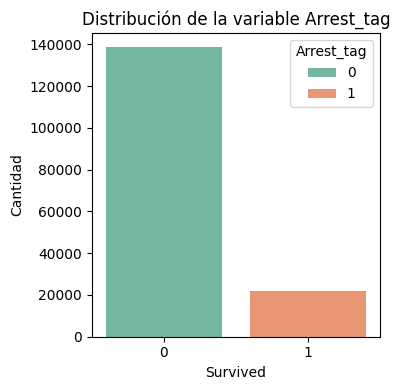

In [26]:
# Separo el dataset en X (variables) y (target)
target = 'Arrest_tag'
X = df.drop(columns=[target])
y = df[target]

# Separa en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

info(y_train) # datos originales

In [28]:
# Guardo el set de test
df_test = pd.concat([X_test, y_test], axis=1)
df_test.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv", index=False)

## Oversampling con SMOTE

Proporción de clases:
Arrest_tag
0    0.5
1    0.5
Name: proportion, dtype: float64

Entropía de Shannon: 1.0


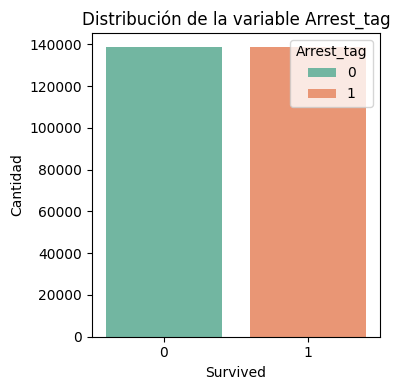

In [18]:
smote = SMOTE(random_state=17)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
info(y_train_sm)

In [29]:
# Guardo el dataset de entrenamiento con oversampling (SMOTE)
df_smote = pd.concat([X_train_sm, y_train_sm], axis=1)
df_smote.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_smote.csv", index=False)

## Undersampling

Proporción de clases:
Arrest_tag
0    0.5
1    0.5
Name: proportion, dtype: float64

Entropía de Shannon: 1.0


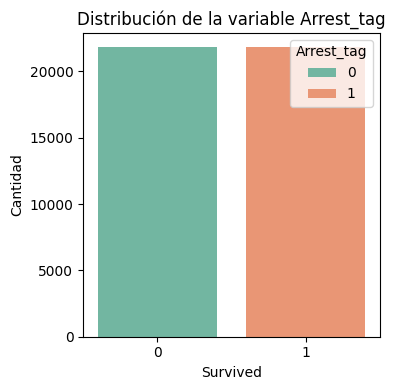

In [27]:
undersample = RandomUnderSampler(random_state=17)
X_train_us, y_train_us = undersample.fit_resample(X_train, y_train)
info(y_train_us)

In [22]:
# Guardo el dataset de entrenamiento con undersampling
df_undersample = pd.concat([X_train_us, y_train_us], axis=1)
df_undersample.to_csv("datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_undersample.csv", index=False)